## Neural Network Model

Next we train a Multi-Layer Perceptron (MLP) regressor to predict rate_avg. Neural networks learn by passing data forward through layers of weighted connections, computing a prediction, and adjusting those weights backwards based on the error. For this model we compare a 2-layer and 3-layer MLP architecture to assess whether adding depth improves predictive performance on our Airbnb dataset.

In [5]:
# load required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             mean_absolute_percentage_error, r2_score)

### Load and Prepare Data

Neural networks are sensitive to the scale of input features. Unlike tree-based models, which split on thresholds and are scale-invariant, MLPs use gradient-based optimization where large differences in feature magnitudes can cause unstable or slow training. We standardize all features to have mean 0 and standard deviation 1 using StandardScaler before training. 

In [6]:
df = pd.read_csv("Use_this_data_for_Modeling_MSE446_cleaned_dataset_postEDA.csv")
print(f"Dataset shape: {df.shape}")

# drop feature we are predicting
X = df.drop(columns=["rate_avg"])
y = df["rate_avg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train size: {X_train_scaled.shape}, Test size: {X_test_scaled.shape}")

Dataset shape: (3225, 71)
Train size: (2580, 70), Test size: (645, 70)


### 2-Layer MLP

We first train a 2-layer MLP with two hidden layers of 100 neurons each, using the ReLU activation function and the Adam optimizer. 

In [7]:
mlp_2layer = MLPRegressor(
    hidden_layer_sizes=(100, 100),  
    activation='relu',              
    solver='adam',                  
    max_iter=500,
    random_state=42
)

mlp_2layer.fit(X_train_scaled, y_train)
y_pred_2layer = mlp_2layer.predict(X_test_scaled)

mse_2  = mean_squared_error(y_test, y_pred_2layer)
rmse_2 = np.sqrt(mse_2)
mae_2  = mean_absolute_error(y_test, y_pred_2layer)
mape_2 = mean_absolute_percentage_error(y_test, y_pred_2layer)
r2_2   = r2_score(y_test, y_pred_2layer)

print("2-Layer MLP Results")
print("MSE: ", mse_2)
print("RMSE:", rmse_2)
print("MAE: ", mae_2)
print("MAPE:", mape_2)
print("R²:  ", r2_2)

2-Layer MLP Results
MSE:  572.1310519885067
RMSE: 23.91926110874888
MAE:  16.100210771277737
MAPE: 0.14613288387902423
R²:   0.946233650798866


C:\Users\Lauren\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


### 3-Layer MLP

We extend the network by adding a third hidden layer to assess whether additional depth helps capture more complex patterns in the data. The third layer uses 50 neurons.

In [8]:
mlp_3layer = MLPRegressor(
    hidden_layer_sizes=(100, 100, 50),  # three hidden layers
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

mlp_3layer.fit(X_train_scaled, y_train)
y_pred_3layer = mlp_3layer.predict(X_test_scaled)

mse_3  = mean_squared_error(y_test, y_pred_3layer)
rmse_3 = np.sqrt(mse_3)
mae_3  = mean_absolute_error(y_test, y_pred_3layer)
mape_3 = mean_absolute_percentage_error(y_test, y_pred_3layer)
r2_3   = r2_score(y_test, y_pred_3layer)

print("3-Layer MLP Results")
print("MSE: ", mse_3)
print("RMSE:", rmse_3)
print("MAE: ", mae_3)
print("MAPE:", mape_3)
print("R²:  ", r2_3)

3-Layer MLP Results
MSE:  729.1169445352302
RMSE: 27.002165552696514
MAE:  17.496995504707296
MAPE: 0.15361490466747152
R²:   0.9314808100135551


### Loss Curves

The loss curves track how training error decreases over each epoch for both models. A smooth downward curve that flattens out indicates the model converged successfully. Comparing both curves helps determine whether the added layer in the 3-layer model leads to faster or more stable convergence.

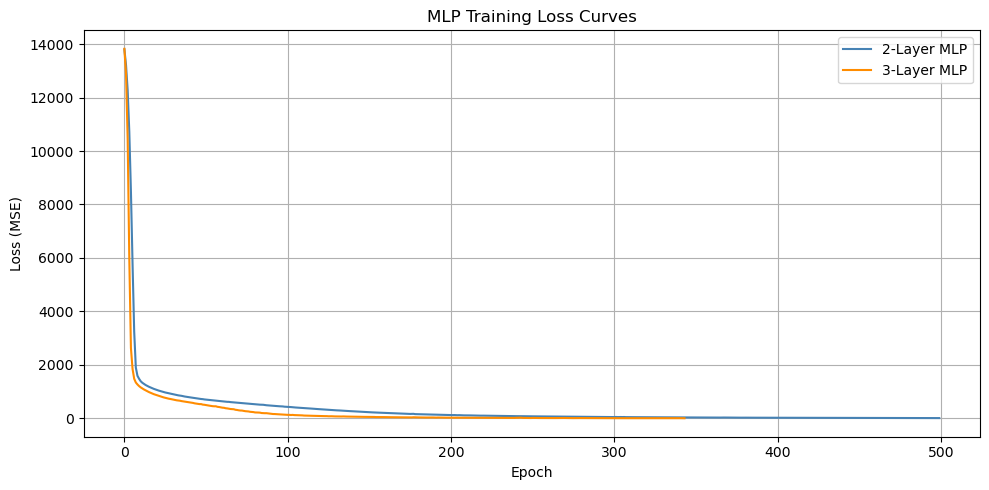

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(mlp_2layer.loss_curve_, label='2-Layer MLP', color='steelblue')
plt.plot(mlp_3layer.loss_curve_, label='3-Layer MLP', color='darkorange')
plt.title("MLP Training Loss Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Actual vs Predicted - Side by Side

These scatter plots compare each model's predicted values against the actual rate_avg values on the test set. Points close to the dashed diagonal line indicate accurate predictions. Comparing both plots side by side shows whether the additional layer produces meaningfully different predictions.

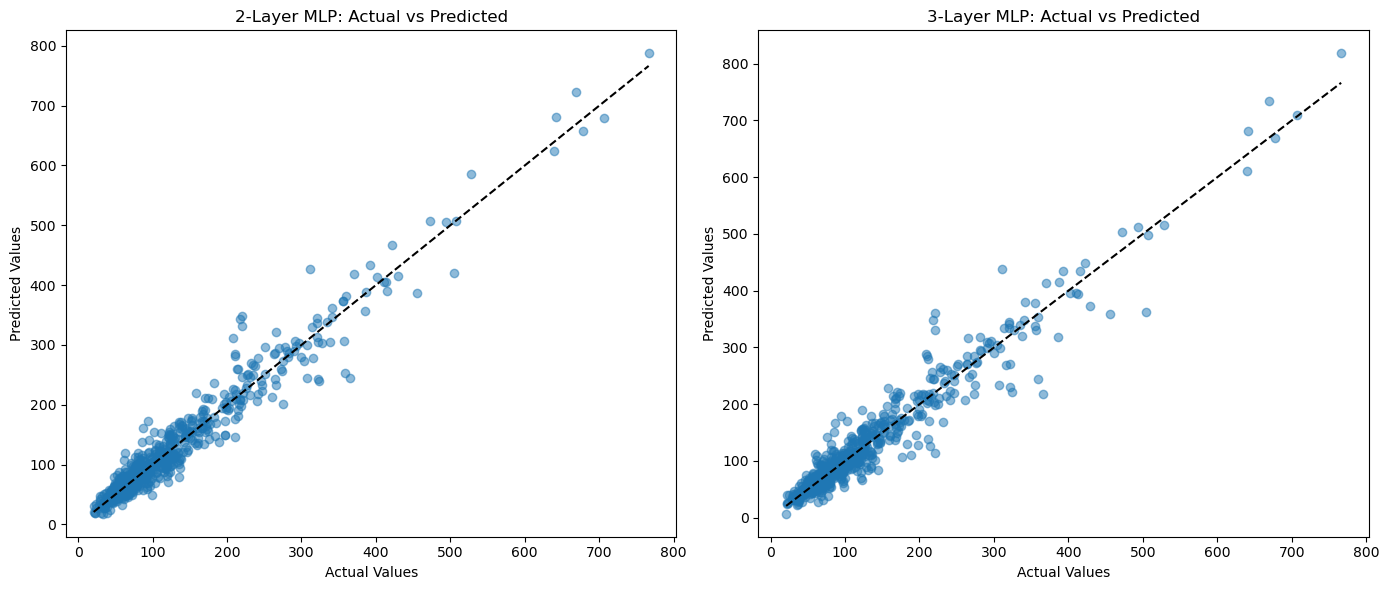

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_pred, title in zip(
    axes,
    [y_pred_2layer, y_pred_3layer],
    ["2-Layer MLP: Actual vs Predicted", "3-Layer MLP: Actual vs Predicted"]
):
    ax.scatter(y_test, y_pred, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'k--')
    ax.set_xlabel("Actual Values")
    ax.set_ylabel("Predicted Values")
    ax.set_title(title)

plt.tight_layout()
plt.show()

### Results Summary

The table below compares both MLP architectures across all standardized error metrics, consistent with the tree-based model comparisons.

In [11]:
mlp_summary = pd.DataFrame([
    {
        "Model": "MLP (2-Layer)",
        "MSE":  round(mse_2, 4),
        "RMSE": round(rmse_2, 4),
        "MAE":  round(mae_2, 4),
        "MAPE": round(mape_2, 4),
        "R²":   round(r2_2, 6),
    },
    {
        "Model": "MLP (3-Layer)",
        "MSE":  round(mse_3, 4),
        "RMSE": round(rmse_3, 4),
        "MAE":  round(mae_3, 4),
        "MAPE": round(mape_3, 4),
        "R²":   round(r2_3, 6),
    }
]).sort_values("RMSE").reset_index(drop=True)

mlp_summary

,Model,MSE,RMSE,MAE,MAPE,R²
0,MLP (2-Layer),572.1311,23.9193,16.1002,0.1461,0.946234
1,MLP (3-Layer),729.1169,27.0022,17.4970,0.1536,0.931481


### Drawbacks of Neural Networks

While MLPs are flexible and capable of capturing complex nonlinear relationships, there are some limitations worth acknowledging in the context of this analysis. Neural networks are often considered black box models, meaning it is difficult to interpret how individual features contribute to predictions, unlike tree-based methods where feature importance scores provide direct insight. Performance is also heavily dependent on input quality, requiring careful feature scaling and preprocessing before training. Finally, MLPs have a large number of parameters and can overfit if not properly regularized, particularly on smaller datasets like ours where tree-based ensemble methods may generalize more reliably.